## **4. FEN ensembling - Transfer learning + Fine tuning**

In this notebook we use an Ensemble Deep Learning technique with the goal of improving overall performance. The training set is built of **224x224-sized patches**, extracted from the original WSI images exploiting the information provided by binary masks. The model, trained with both transfer learning and fine tuning, consists of **3 parallel FEN backbones (EfficientNet-B3, MobileNet-V3 and ResNet-18)** that process each patch independently, generating 3 distinct feature representations; these are then concatenated (to generate the overall patch latent representation) and fed to an MPL classifier. WSI-level predictions are generated by averaging patch-level softmax probabilities per WSI.

## 🌐 **Google Drive Connection**

In [ ]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/My\\ Drive/challenge2AN2DL"
%cd $current_dir

## ⚙️ **Libraries Import and Parameter Setting**

In [ ]:
# Parameters
SEED = 43
experiment_name = "ensemble_fine_tuning"
sub_filename = "ensemble_fine_tuning"

# True to perform inference and generate csv
MAKE_INFERENCE = False

# Define the batch size
BATCH_SIZE = 16

# Training parameters (TL only)
LEARNING_RATE = 7e-5
EPOCHS = 200
PATIENCE = 20
SMOOTHING_FACTOR = 0

# Regularization
DROPOUT_RATE = 0.3
L2_LAMBDA = 7e-4

# Fine-tuning training parameters
FT_LEARNING_RATE = 7e-6
FT_EPOCHS = 100
FT_PATIENCE = 15
FT_L2_LAMBDA = 1e-3
N_UNFREEZE_LAYERS_EB3 = 1
N_UNFREEZE_LAYERS_R18 = 1
N_UNFREEZE_LAYERS_MV3 = 1

In [ ]:
# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
from glob import glob

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader

# Tensorboard configuration
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
from concurrent.futures import ThreadPoolExecutor
import pickle
from sklearn.model_selection import StratifiedGroupKFold
import torch.nn.functional as F

!pip install lion-pytorch
from lion_pytorch import Lion

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

## ⏳ **Data Loading**

In [ ]:
# train_data_dictionary = { "img_XXXX.png" : (224,224,3) }, where:
#   - XXXX is the zero-padded patch index
#   - (224,224,3) is a 3D matrix describing the patch
#   - pixel values are already between 0 and 1
dict_path = "dataset/patches_224/train_data_dictionary.pkl"

with open(dict_path, "rb") as f:
    X_train_val_dict = pickle.load(f)

print("Train data dictionary loaded! Number of images: ", len(X_train_val_dict))
print("Examples of image names: ", list(X_train_val_dict.keys())[:5])

# "cleaned_patched_train_labels.csv" is a csv file with the following columns:
#   - "index" -> patch index
#   - "label" -> label of the WSI from which the patch was extracted
#   - "original_idx" -> index of the WSI from which the patch was extracted
y_train_val_df = pd.read_csv('dataset/patches_224/cleaned_patched_train_labels.csv')
y_train_val_df['index'] = y_train_val_df['index'].astype(int)
y_train_val_df['filename'] = y_train_val_df['index'].apply(lambda x: f"img_{x:04d}.png")

unique_labels = sorted(y_train_val_df['label'].unique().tolist())
print("Train labels loaded! Unique labels: ", unique_labels)
print("Number of original images: ", y_train_val_df['original_idx'].nunique())

Train data dictionary loaded! Number of images:  2763
Examples of image names:  ['img_0001.png', 'img_0002.png', 'img_0003.png', 'img_0004.png', 'img_0005.png']
Train labels loaded! Unique labels:  ['HER2(+)', 'Luminal A', 'Luminal B', 'Triple negative']
Number of original images:  581


In [ ]:
# Label distribution in the training-validation set
label_counts = y_train_val_df['label'].value_counts().sort_index()

print("Class distribution:\n")
for label, count in label_counts.items():
    print(f"Label {label}: {count/len(y_train_val_df)} samples")

Class distribution:

Label HER2(+): 0.26601520086862107 samples
Label Luminal A: 0.2703583061889251 samples
Label Luminal B: 0.35685848715164675 samples
Label Triple negative: 0.1067680057908071 samples


##  📄 **Data Preprocessing**

In [ ]:
# This function takes in input the training-validation dictionary and the training-validation dataframe
# It performs stratified splitting between training and validation set, avoiding data leakage (patches belonging to the same WSI will be in the same set)
# It returns the splitted dataframes and dictionaries for training and validation

def stratified_group_split(df, X_dict, val_size=0.2, random_state=42):

    # Input check
    assert 'label' in df.columns
    assert 'original_idx' in df.columns
    assert 'filename' in df.columns

    y = df['label'].values
    groups = df['original_idx'].values

    # K-fold splitting
    n_splits = int(round(1.0 / val_size))
    if n_splits < 2:
        raise ValueError("val_size too big, should be < 0.5.")

    sgkf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    # We take one fold for validation, the other ones are used for training
    X_placeholder = np.zeros(len(df))
    train_idx, val_idx = next(sgkf.split(X_placeholder, y, groups))

    # Training and validation dataframes
    df_train = df.iloc[train_idx].reset_index(drop=True)
    df_val   = df.iloc[val_idx].reset_index(drop=True)

    train_filenames = df_train['filename'].values
    val_filenames   = df_val['filename'].values

    # Training and validation dictionaries
    X_train_dict = {fn: X_dict[fn] for fn in train_filenames}
    X_val_dict   = {fn: X_dict[fn] for fn in val_filenames}

    # Label distribution in the training and validation sets
    print("Dimensions:")
    print("  train:", len(X_train_dict), "patch")
    print("  val  :", len(X_val_dict), "patch")
    print()

    print("TRAIN label distribution:")
    print(df_train['label'].value_counts().sort_index()/len(X_train_dict))
    print("\nVAL label distribution:")
    print(df_val['label'].value_counts().sort_index()/len(X_val_dict))
    print("\nTOTAL label distribution:")
    print(df['label'].value_counts().sort_index()/len(X_dict))

    # Data leakage check
    n_leakages = len(set(df_train['original_idx']).intersection(set(df_val['original_idx'])))
    print("\nNumber of data leakage occurrences:", n_leakages)

    return X_train_dict, X_val_dict, df_train, df_val

In [ ]:
# 80-20 training-validation splitting
X_train_dict, X_val_dict, y_train_df, y_val_df = stratified_group_split(
    y_train_val_df,
    X_train_val_dict,
    val_size=0.2,
    random_state=SEED
)

Dimensions:
  train: 2248 patch
  val  : 515 patch

TRAIN label distribution:
label
HER2(+)            0.276690
Luminal A          0.256673
Luminal B          0.358541
Triple negative    0.108096
Name: count, dtype: float64

VAL label distribution:
label
HER2(+)            0.219417
Luminal A          0.330097
Luminal B          0.349515
Triple negative    0.100971
Name: count, dtype: float64

TOTAL label distribution:
label
HER2(+)            0.266015
Luminal A          0.270358
Luminal B          0.356858
Triple negative    0.106768
Name: count, dtype: float64

Number of data leakage occurrences: 0


In [ ]:
# This funcion takes in input the training (or validation) dictionary and dataframe
# It returns a numpy matrix containing the pixel values of all the patches and a numpy array of patch labels

def build_xy_from_dict_and_df(X_dict, y_df):

    filenames = y_df['filename'].values

    # We contruct an ordered patch list
    X_list = []
    for fn in filenames:
        img = X_dict[fn]              # (H, W, 3)
        # HWC -> CHW tranformation for PyTorch compatibility
        img_chw = np.transpose(img, (2, 0, 1))   # (3, H, W)
        X_list.append(img_chw)

    # 4D matrix of pixels (N_patches, 3, 224, 224)
    X = np.stack(X_list, axis=0).astype(np.float32)

    # Label array
    y = y_df['label'].values

    return X, y

In [ ]:
# Building of pixel matrices and label arrays
X_train, y_train = build_xy_from_dict_and_df(X_train_dict, y_train_df)
X_val, y_val = build_xy_from_dict_and_df(X_val_dict, y_val_df)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (2248, 3, 224, 224)
y_train shape: (2248,)
X_val shape: (515, 3, 224, 224)
y_val shape: (515,)


In [ ]:
# Map the categorical labels to numerical values

label_mapping = {
    "HER2(+)": 0,
    "Luminal A": 1,
    "Luminal B": 2,
    "Triple negative": 3
}

y_train = np.array([label_mapping[x] for x in y_train])
y_val = np.array([label_mapping[x] for x in y_val])


print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

y_train shape: (2248,)
y_val shape: (515,)


In [ ]:
# Define the input shape and number of classes
input_shape = (3, 224, 224)
num_classes = 4

print("Input Shape:", input_shape)
print("Number of Classes:", num_classes)

Input Shape: (3, 224, 224)
Number of Classes: 4


In [ ]:
# ImageNet normalization statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class TissueDataset(torch.utils.data.Dataset):
    """Custom PyTorch Dataset for Oxford Pets with optional augmentation and normalization."""

    def __init__(self, data, labels, augmentation=None, normalize_imagenet=False):
        """
        Args:
            data: numpy array of images (N, C, H, W) in range [0, 1]
            labels: numpy array of labels
            augmentation: transforms for data augmentation
            normalize_imagenet: whether to apply ImageNet normalization
        """
        self.data = torch.from_numpy(data)
        self.labels = torch.from_numpy(labels).long()
        self.augmentation = augmentation
        self.normalize_imagenet = normalize_imagenet

        # ImageNet normalization transform
        if normalize_imagenet:
            self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        else:
            self.normalize = None

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].clone()  # Clone to avoid modifying original
        label = self.labels[idx]

        # Apply augmentation if provided (on images in [0, 1] range)
        if self.augmentation:
            image = self.augmentation(image)

        # Apply ImageNet normalization if requested
        if self.normalize:
            image = self.normalize(image)

        return image, label

In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last):
    """Create a PyTorch DataLoader with optimized settings."""
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,
    )

##  🧮 **Network Parameters**

In [ ]:
# Setup weighted cross-entropy loss
class_distributions = {
    cls: np.sum(y_train == cls) / len(y_train)
    for cls in [0, 1, 2, 3]
}
class_weights = list(class_distributions.values())
class_weights = [1/x for x in class_weights]
print(class_weights)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(device), label_smoothing=SMOOTHING_FACTOR)

# Print the defined parameters
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Learning Rate:", LEARNING_RATE)
print("Dropout Rate:", DROPOUT_RATE)
print("Patience:", PATIENCE)

[np.float64(3.6141479099678455), np.float64(3.896013864818024), np.float64(2.7890818858560795), np.float64(9.251028806584362)]
Epochs: 200
Batch Size: 16
Learning Rate: 7e-05
Dropout Rate: 0.3
Patience: 20


## 🧠 **Model Training**

In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer) # Explicitly unscale gradients
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [ ]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [ ]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

## 🛠️ **Transfer Learning**

In [ ]:
#-------------------------------
# Backbone FEN 1: EfficientNet-B3
#-------------------------------
class EffB3Features(nn.Module):
    def __init__(self, freeze_backbone=True):
        super().__init__()
        m = torchvision.models.efficientnet_b3(
            weights=torchvision.models.EfficientNet_B3_Weights.DEFAULT
        )
        self.features = m.features          # convolutional trunk (Sequential of MBConv blocks)
        self.pool = m.avgpool              # AdaptiveAvgPool2d(1)

        if freeze_backbone:
            for p in self.features.parameters():
                p.requires_grad = False

    def forward(self, x):
        x = self.features(x)               # [B, C, H, W]
        x = self.pool(x)                   # [B, C, 1, 1]
        x = torch.flatten(x, 1)            # [B, C]
        return x

    def unfreeze_last_blocks(self, n_blocks=2):
        """
        Unfreeze the last n_blocks MBConv blocks of EfficientNet-B3.
        """
        blocks = list(self.features.children())
        for block in blocks[-n_blocks:]:
            for p in block.parameters():
                p.requires_grad = True


#-------------------------------
# Backbone FEN 2: ResNet 18
#-------------------------------
class ResNet18Features(nn.Module):
    def __init__(self, freeze_backbone=True):
        super().__init__()
        m = torchvision.models.resnet18(
            weights=torchvision.models.ResNet18_Weights.DEFAULT
        )
        # all layers up to (and including) avgpool, excluding final FC:
        # children: [conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool]
        self.features = nn.Sequential(*list(m.children())[:-1])  # -> [B, 512, 1, 1]

        if freeze_backbone:
            for p in self.features.parameters():
                p.requires_grad = False

    def forward(self, x):
        x = self.features(x)               # [B, 512, 1, 1]
        x = torch.flatten(x, 1)            # [B, 512]
        return x

    def unfreeze_last_residual_stages(self, n_stages=1):
        """
        Unfreeze the last n_stages among {layer1, layer2, layer3, layer4}.
        """
        modules = list(self.features.children())
        # select only the residual layers
        residual_stages = [m for m in modules if isinstance(m, nn.Sequential)]
        # residual_stages correspond to [layer1, layer2, layer3, layer4]
        for stage in residual_stages[-n_stages:]:
            for p in stage.parameters():
                p.requires_grad = True

#-------------------------------
# Backbone FEN 3: MobileNet V3
#-------------------------------
class MobileNetV3SmallFeatures(nn.Module):
    def __init__(self, freeze_backbone=True):
        super().__init__()
        m = torchvision.models.mobilenet_v3_small(
            weights=torchvision.models.MobileNet_V3_Small_Weights.DEFAULT
        )
        self.features = m.features          # Sequential of inverted residual blocks
        self.pool = m.avgpool              # AdaptiveAvgPool2d(1)

        if freeze_backbone:
            for p in self.features.parameters():
                p.requires_grad = False

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)                   # [B, C, 1, 1]
        x = torch.flatten(x, 1)            # [B, C]
        return x

    def unfreeze_last_blocks(self, n_blocks=3):
        """
        Unfreeze the last n_blocks of MobileNetV3-Small features.
        """
        blocks = list(self.features.children())
        for block in blocks[-n_blocks:]:
            for p in block.parameters():
                p.requires_grad = True


In [ ]:
# The model consists of 3 parallel FEN backbones that extract features from patches; the features are then concatenated to
#     generate the final latent representation for the patch, which is finally processed by a MPL classifier

class MultiBackboneEnsembleB3Res18MobSmall(nn.Module):
    def __init__(self, num_classes, img_size=224, dropout=0.3,
                 freeze_backbones=True):
        super().__init__()

        # Parallel FEN backbones
        self.eff = EffB3Features(freeze_backbone=freeze_backbones)
        self.res = ResNet18Features(freeze_backbone=freeze_backbones)
        self.mob = MobileNetV3SmallFeatures(freeze_backbone=freeze_backbones)

        # Final feature dimension computation
        with torch.no_grad():
            dummy = torch.zeros(1, 3, img_size, img_size)
            eff_dim = self.eff(dummy).shape[1]
            res_dim = self.res(dummy).shape[1]
            mob_dim = self.mob(dummy).shape[1]

        total_dim = eff_dim + res_dim + mob_dim
        print(f"Feature dims: eff={eff_dim}, res={res_dim}, mob={mob_dim}, total={total_dim}")

        # MLP classification head
        self.classifier = nn.Sequential(
            nn.Linear(total_dim, 512),
            nn.LayerNorm(512),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        f_eff = self.eff(x)   # [B, eff_dim]
        f_res = self.res(x)   # [B, res_dim]
        f_mob = self.mob(x)   # [B, mob_dim]

        # The features generated by the parallel backbones are concatenated
        f = torch.cat([f_eff, f_res, f_mob], dim=1)
        logits = self.classifier(f)
        return logits

    def unfreeze_backbones(self,
                           eff_last_blocks=2,
                           res_last_stages=1,
                           mob_last_blocks=3):
        """
        Unfreeze only the last parts of each backbone for fine-tuning.
        """
        self.eff.unfreeze_last_blocks(n_blocks=eff_last_blocks)
        self.res.unfreeze_last_residual_stages(n_stages=res_last_stages)
        self.mob.unfreeze_last_blocks(n_blocks=mob_last_blocks)


In [ ]:
# Define the model, starting with frozen backbones for transfer learning
model = MultiBackboneEnsembleB3Res18MobSmall(
    num_classes=num_classes,
    img_size=224,
    dropout=DROPOUT_RATE,
    freeze_backbones=True
).to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 180MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 72.5MB/s]


Feature dims: eff=1536, res=512, mob=576, total=2624


In [ ]:
# Define augmentation for training patches
train_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(degrees=72, translate=(0.2, 0.2)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15)
])

# Create datasets WITH ImageNet normalization
train_tl_ds = TissueDataset(X_train, y_train, augmentation=train_augmentation, normalize_imagenet=True)
val_tl_ds = TissueDataset(X_val, y_val, augmentation=None, normalize_imagenet=True)

# Create data loaders for training and validation sets
train_tl_loader = make_loader(train_tl_ds, BATCH_SIZE, shuffle=True, drop_last=False)
val_tl_loader = make_loader(val_tl_ds, BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
# Setup training
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)

# Lion optimizer
optimizer = Lion(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Scaler
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [ ]:
%%time
# Train with transfer learning
tl_model, training_history = fit(
    model=model,
    train_loader=train_tl_loader,
    val_loader=val_tl_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name=experiment_name,
    patience=PATIENCE
)

# Update best model if current performance is superior
if max(training_history['val_f1']) > best_performance:
    best_model = tl_model
    best_performance = max(training_history['val_f1'])


Training 200 epochs...
Epoch   1/200 | Train: Loss=1.3704, F1 Score=0.3191 | Val: Loss=1.2832, F1 Score=0.3343
Epoch   2/200 | Train: Loss=1.3292, F1 Score=0.3387 | Val: Loss=1.2917, F1 Score=0.3869
Epoch   3/200 | Train: Loss=1.3103, F1 Score=0.3570 | Val: Loss=1.2747, F1 Score=0.3866
Epoch   4/200 | Train: Loss=1.2880, F1 Score=0.4024 | Val: Loss=1.2717, F1 Score=0.3809
Epoch   5/200 | Train: Loss=1.2726, F1 Score=0.3883 | Val: Loss=1.3044, F1 Score=0.4164
Epoch   6/200 | Train: Loss=1.2578, F1 Score=0.4107 | Val: Loss=1.2918, F1 Score=0.3890
Epoch   7/200 | Train: Loss=1.2548, F1 Score=0.4041 | Val: Loss=1.2908, F1 Score=0.3896
Epoch   8/200 | Train: Loss=1.2590, F1 Score=0.3946 | Val: Loss=1.2794, F1 Score=0.3987
Epoch   9/200 | Train: Loss=1.2473, F1 Score=0.4113 | Val: Loss=1.3205, F1 Score=0.3939
Epoch  10/200 | Train: Loss=1.2161, F1 Score=0.4378 | Val: Loss=1.3358, F1 Score=0.3737
Epoch  11/200 | Train: Loss=1.2187, F1 Score=0.4369 | Val: Loss=1.3263, F1 Score=0.3799
Epoch  12

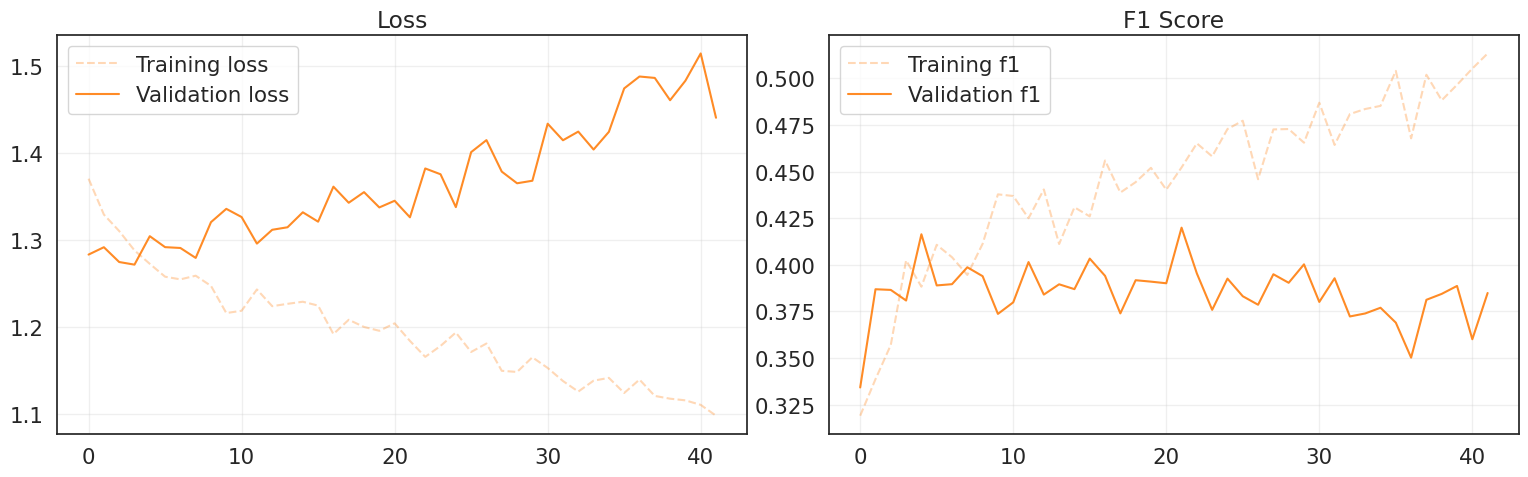

In [ ]:
# @title Plot Hitory
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

## 🛠️ **Fine-Tuning**

In [ ]:
# New optimizer
def make_optimizer_for_trainable_params(model, lr, weight_decay):
    params = [p for p in model.parameters() if p.requires_grad]
    return Lion(params, lr=lr, weight_decay=weight_decay)

In [ ]:
# Define the fine tuning model
ft_model = tl_model

# Unfreeze last layers of the backbones for fine tuning
ft_model.unfreeze_backbones(
    eff_last_blocks=N_UNFREEZE_LAYERS_EB3,
    res_last_stages=N_UNFREEZE_LAYERS_R18,
    mob_last_blocks=N_UNFREEZE_LAYERS_MV3
)

# Training setup
ft_optimizer = make_optimizer_for_trainable_params(
    ft_model,
    lr=FT_LEARNING_RATE,
    weight_decay=FT_L2_LAMBDA
)
ft_writer = SummaryWriter("./" + logs_dir + "/" + experiment_name + "_finetune")
ft_scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [ ]:
# Fine tuning
ft_model, ft_history = fit(
    model=ft_model,
    train_loader=train_tl_loader,
    val_loader=val_tl_loader,
    epochs=FT_EPOCHS,
    criterion=criterion,
    optimizer=ft_optimizer,
    scaler=ft_scaler,
    device=device,
    writer=ft_writer,
    verbose=1,
    experiment_name=experiment_name + "_FT",
    patience=FT_PATIENCE
)

# Update best model if current performance is superior
if max(ft_history['val_f1']) > best_performance:
    best_model = ft_model
    best_performance = max(ft_history['val_f1'])

Training 100 epochs...
Epoch   1/100 | Train: Loss=1.1972, F1 Score=0.4400 | Val: Loss=1.3235, F1 Score=0.4114
Epoch   2/100 | Train: Loss=1.1799, F1 Score=0.4696 | Val: Loss=1.3496, F1 Score=0.3787
Epoch   3/100 | Train: Loss=1.1202, F1 Score=0.4784 | Val: Loss=1.3955, F1 Score=0.3793
Epoch   4/100 | Train: Loss=1.1444, F1 Score=0.4762 | Val: Loss=1.3733, F1 Score=0.3911
Epoch   5/100 | Train: Loss=1.1233, F1 Score=0.4775 | Val: Loss=1.4075, F1 Score=0.3859
Epoch   6/100 | Train: Loss=1.0873, F1 Score=0.5188 | Val: Loss=1.4591, F1 Score=0.3716
Epoch   7/100 | Train: Loss=1.0849, F1 Score=0.5151 | Val: Loss=1.4671, F1 Score=0.4005
Epoch   8/100 | Train: Loss=1.0838, F1 Score=0.5120 | Val: Loss=1.4349, F1 Score=0.4209
Epoch   9/100 | Train: Loss=1.0708, F1 Score=0.5161 | Val: Loss=1.4408, F1 Score=0.4116
Epoch  10/100 | Train: Loss=1.0266, F1 Score=0.5354 | Val: Loss=1.4514, F1 Score=0.3969
Epoch  11/100 | Train: Loss=1.0364, F1 Score=0.5409 | Val: Loss=1.4990, F1 Score=0.4106
Epoch  12

## 🧠 **Inference**

In [ ]:
# ImageNet normalization statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class TissueTestDataset(torch.utils.data.Dataset):
    """Custom PyTorch Dataset for Oxford Pets with optional augmentation and normalization."""

    def __init__(self, data, augmentation=None, normalize_imagenet=False):

        """
        Args:
            data: numpy array of images (N, C, H, W) in range [0, 1]
            augmentation: transforms for data augmentation
            normalize_imagenet: whether to apply ImageNet normalization
        """

        self.data = torch.from_numpy(data)
        self.augmentation = augmentation
        self.normalize_imagenet = normalize_imagenet


        # ImageNet normalization transform
        if normalize_imagenet:
            self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        else:
            self.normalize = None

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].clone()  # Clone to avoid modifying original

        # Apply augmentation if provided (on images in [0, 1] range)
        if self.augmentation:
            image = self.augmentation(image)

        # Apply ImageNet normalization if requested
        if self.normalize:
            image = self.normalize(image)

        return image

In [ ]:
if MAKE_INFERENCE:
    # test_data is a directory containing png test patches
    test_dir  = 'dataset/patches_224/test_data'
    # "cleaned_patched_test_indices.csv" is a csv file with the following columns:
    #   - "index" -> patch index
    #   - "original_idx" -> index of the WSI from which the patch was extracted
    test_map_csv = 'dataset/patches_224/cleaned_patched_test_indices.csv'

    # Load the csv file
    df = pd.read_csv(test_map_csv)
    df['index'] = df['index'].astype(int)
    df['filename'] = df['index'].apply(lambda x: f"img_{x:04d}.png")
    filenames = df['filename'].tolist()

    # Function for test patch loading
    def load_one_image(filename):
        img_path = os.path.join(test_dir, filename)
        img = Image.open(img_path).convert('RGB')
        img_array = (np.array(img, dtype=np.float32) / 255.0)
        img_array = np.transpose(img_array, (2, 0, 1))
        return img_array

    test_array = []

    i = 1
    # Multiple workers to speed up the loading process
    with ThreadPoolExecutor(max_workers=16) as executor:
        for arr in executor.map(load_one_image, filenames):
            test_array.append(arr)
            if i % 50 == 0:
              print(f"{i}/{len(filenames)}")
            i += 1

    # (N_patches, 3, 224, 224) numpy matrix containing the pixel values (between 0 and 1) of all the test patches
    X_test = np.stack(test_array, axis=0)
    print(X_test.shape)

In [ ]:
if MAKE_INFERENCE:
  # Create data loader for test set
    test_ds = TissueTestDataset(X_test, augmentation=None, normalize_imagenet=True)
    test_loader = make_loader(test_ds, BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
def inference(model, test_loader, device):
    """
    Perform inference on the test dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        test_loader (DataLoader): PyTorch DataLoader containing test data batches
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        list: A list of numpy arrays, where each array contains predictions for a batch.
    """

    model.eval()  # Set model to evaluation mode

    all_probs = []

    # Disable gradient computation for inference
    with torch.no_grad():
        for inputs in test_loader:
            # Move data to device
            inputs = inputs.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)

            # Accumulate probabilities
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())

    return all_probs

In [ ]:
if MAKE_INFERENCE:
    # Perform inference on the test patches
    probabilities = inference(ft_model, test_loader, device)

    # Generate a numpy matrix containing the softmax probabilities for each patch
    probabilities = np.concatenate(probabilities, axis=0)

In [ ]:
if MAKE_INFERENCE:
    test_mapping = pd.read_csv(test_map_csv)

    # Attach the wsi index to each corresponding row of patch probabilities
    orig_idx = test_mapping["original_idx"].values

    # Create the corresponding dataframe
    probs_df = pd.DataFrame(probabilities)
    probs_df["original_idx"] = orig_idx

    # Average probabilities per wsi
    avg_probs_df = probs_df.groupby("original_idx").mean()

    # Convert back to numpy
    avg_probs = avg_probs_df.to_numpy()           # shape: (num_original_samples, num_classes)

    # Final predictions: argmax over classes
    predictions = avg_probs.argmax(axis=1).tolist()        # shape: (num_original_samples,)

In [ ]:
if MAKE_INFERENCE:
    # Inverse label mapping for submission csv file
    mapping_label = {
        0: "HER2(+)",
        1: "Luminal A",
        2: "Luminal B",
        3: "Triple negative"
    }

    # Submission csv generation
    pred_df = pd.DataFrame({
        "sample_index": [f"img_{i:04d}.png" for i in range(len(predictions))],
        "label": [mapping_label[int(x)] for x in predictions]
    })

    pred_df.to_csv("submissions/"+sub_filename+".csv", index=False)